# СИМА — ЦМД и детекция деревьев на Юильском: сверка с эталоном и время

Ноутбук берёт ВЛС из S3, строит ЦМД (растр высот полога), находит вершины деревьев
и кроны, замеряет время каждого шага и сверяет результат с эталоном — выгрузкой,
посчитанной в СИМА 1.44 и лежащей в том же бакете.

## Источник данных

| Компонент | Расположение в бакете `geomate-project` | Использование |
|---|---|---|
| **ВЛС (ТЛО)** | `СИМА/Datasets/Юильский/LAS/<stem>_ground_TLO.las` | вход: облако точек |
| **Эталон** | `СИМА/Datasets/Юильский/Forest/<N>_<диапазон>/<stem>_ground_localMax.shp` | вершины деревьев из СИМА 1.44 |
| **АФС (ОФП)** | `СИМА/Datasets/Юильский/ОФП/MSK86z2/<stem>.tif` | СК, фон картинок, вегетационная маска |

## Почему ЦМД не требует ни ЦММ, ни абсолютных высот

ЦМД строится отдельным проходом PDAL по облаку: `filters.hag_delaunay` считает
превышение каждой точки над триангулированной поверхностью земли, затем `Z`
заменяется этим превышением и растеризуется максимумом в ячейке. Нормализация
происходит внутри модуля, поэтому облако в ТЛО (как здесь) и облако в абсолютных
отметках дают один и тот же результат.

Это отличает ЦМД от ЦМР: там абсолютный уровень существен, и на ТЛО ЦМР вырождается
в константу. ЦМД же вычитанием ЦММ из ЦМР не строится и их наличия не требует.

## Параметры эксперта (СИМА 1.44, Юильский, лето)

Разрешение ЦМД 0.5 м, медианное сглаживание 1 м, окно поиска вершин крон 1 м;
гари и ветровал не строились. Эти значения стоят по умолчанию ниже — на них
проверяется сходимость с эталоном.

## 1. Настройка окружения

In [1]:
import json, os, shutil, sys, time, traceback, unicodedata, warnings
from pathlib import Path, PurePosixPath

warnings.filterwarnings('ignore')

BACKEND = Path('/Users/sergeyzay/Documents/НЕДРА/СИМА/sima-web/backend')
os.environ['PATH'] = '/opt/homebrew/bin:' + os.environ.get('PATH', '')

for _pkg in ('packages/sima-dem-core/src', 'packages/sima-forest-cmd/src'):
    _p = str(BACKEND / _pkg)
    if _p not in sys.path:
        sys.path.insert(0, _p)

import boto3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from matplotlib.colors import ListedColormap
from osgeo import ogr
from rasterio.windows import from_bounds

from sima_forest_cmd import (
    CHMBuilder, CHMConfig, read_chm,
    detect_tree_tops, to_world, split_by_height,
    delineate_crowns, crowns_to_polygons, crown_areas_by_tree,
    estimate_stem_diameter, write_tree_points, write_crown_polygons,
    vegetation_mask, resample_mask_to_grid, correct_tops,
)

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)
plt.rcParams['figure.dpi'] = 110
print('sima-forest-cmd загружен')

sima-forest-cmd загружен


## 2. Параметры прогона

| Переменная | Смысл |
|---|---|
| `RESOLUTION` / `WINDOW_M` | разрешение ЦМД и окно поиска вершин — параметры эксперта |
| `LIMIT` / `PREVIEW_EVERY` | сколько тайлов обработать и как часто рисовать картинки |
| `COMPARE_RESOLUTIONS` | дополнительный прогон на метровой сетке для сравнения |
| `AFS_CORRECTION` | этап 2: отсев и уточнение вершин по снимку |

Ключи доступа берутся из переменных окружения `S3_ACCESS_KEY` / `S3_SECRET_KEY`,
иначе из `backend/.s3_credentials.json` (файл в `.gitignore`).

In [2]:
S3_ENDPOINT = 'https://storage.yandexcloud.net'
S3_REGION   = 'ru-central1'
BUCKET      = 'geomate-project'

S3_ACCESS_KEY = os.environ.get('S3_ACCESS_KEY', '')
S3_SECRET_KEY = os.environ.get('S3_SECRET_KEY', '')
if not (S3_ACCESS_KEY and S3_SECRET_KEY):
    _cred = BACKEND / '.s3_credentials.json'
    if _cred.exists():
        _c = json.loads(_cred.read_text(encoding='utf-8'))
        S3_ACCESS_KEY, S3_SECRET_KEY = _c['access_key'], _c['secret_key']
if not (S3_ACCESS_KEY and S3_SECRET_KEY):
    raise RuntimeError('Нет ключей S3: задайте S3_ACCESS_KEY/S3_SECRET_KEY в окружении '
                       'или создайте backend/.s3_credentials.json')

nfd = lambda s: unicodedata.normalize('NFD', s)   # ключи в бакете — в форме NFD

LAS_PREFIX    = nfd('СИМА/Datasets/Юильский/LAS/')
AFS_PREFIX    = nfd('СИМА/Datasets/Юильский/ОФП/MSK86z2/')
FOREST_PREFIX = nfd('СИМА/Datasets/Юильский/Forest/')
LAS_SUFFIX    = '_ground_TLO'
REF_SUFFIX    = '_ground_localMax'

# --- параметры расчёта (значения эксперта, СИМА 1.44) ------------------
RESOLUTION   = 0.5     # разрешение ЦМД, м
WINDOW_M     = 1.0     # окно поиска вершин крон, м
MEDIAN_PX    = 1       # радиус медианного сглаживания ЦМД, px
MIN_HEIGHT_M = 0.5     # ниже — не дерево
SHRUB_M      = 5.0     # граница «кустарник / древостой»

# --- прогон -----------------------------------------------------------
LIMIT                = 12
OFFSET               = 0
PREVIEW_EVERY        = 4
COMPARE_RESOLUTIONS  = [1.0]    # доп. прогоны для сравнения; [] — только основной
AFS_CORRECTION       = False    # этап 2: отсев и уточнение вершин по снимку
AFS_EXG_THRESHOLD    = 0.05
KEEP_OUTPUTS         = False
CACHE_LAS            = False
RUN                  = True
RESUME               = True

RESULTS_DIR  = BACKEND / 'benchmarks' / 'results_s3_forest_yuilskiy'
RESULTS_PATH = RESULTS_DIR / 'results.jsonl'
PREVIEW_DIR  = RESULTS_DIR / 'previews'
WORK_ROOT    = RESULTS_DIR / '_work'
CACHE_DIR    = RESULTS_DIR / '_las_cache'
for _d in (RESULTS_DIR, PREVIEW_DIR, WORK_ROOT, CACHE_DIR):
    _d.mkdir(parents=True, exist_ok=True)

os.environ.update(
    AWS_ACCESS_KEY_ID=S3_ACCESS_KEY, AWS_SECRET_ACCESS_KEY=S3_SECRET_KEY,
    AWS_S3_ENDPOINT=S3_ENDPOINT.split('://')[-1], AWS_VIRTUAL_HOSTING='FALSE',
    AWS_DEFAULT_REGION=S3_REGION, GDAL_DISABLE_READDIR_ON_OPEN='EMPTY_DIR',
)
s3 = boto3.client('s3', endpoint_url=S3_ENDPOINT, region_name=S3_REGION,
                  aws_access_key_id=S3_ACCESS_KEY, aws_secret_access_key=S3_SECRET_KEY)
vsis3 = lambda key: f'/vsis3/{BUCKET}/{key}'

print(f'ЦМД {RESOLUTION} м, окно {WINDOW_M} м, медиана {MEDIAN_PX} px')
print(f'LIMIT={LIMIT}  PREVIEW_EVERY={PREVIEW_EVERY}  '
      f'сравнение разрешений: {COMPARE_RESOLUTIONS or "нет"}  АФС: {AFS_CORRECTION}')

ЦМД 0.5 м, окно 1.0 м, медиана 1 px
LIMIT=12  PREVIEW_EVERY=4  сравнение разрешений: [1.0]  АФС: False


## 3. Каталог бакета: ВЛС, АФС и эталон

Эталон разложен по подпапкам с номерами, поэтому индексируется рекурсивным
листингом с отбором по суффиксу имени.

In [3]:
def s3_index(prefix, ext, strip_suffix=''):
    # Индекс объектов бакета по стему имени: {stem: (key, size_bytes)}
    out = {}
    for page in s3.get_paginator('list_objects_v2').paginate(Bucket=BUCKET, Prefix=prefix):
        for o in page.get('Contents', []):
            if not o['Key'].lower().endswith(ext):
                continue
            stem = PurePosixPath(o['Key']).stem
            if strip_suffix:
                if not stem.endswith(strip_suffix):
                    continue
                stem = stem[: -len(strip_suffix)]
            out.setdefault(stem, (o['Key'], o['Size']))
    return out

t0 = time.perf_counter()
LAS_INDEX = s3_index(LAS_PREFIX, '.las', LAS_SUFFIX)
AFS_INDEX = s3_index(AFS_PREFIX, '.tif')
REF_INDEX = s3_index(FOREST_PREFIX, '.shp', REF_SUFFIX)
print(f'листинг бакета: {time.perf_counter() - t0:.1f} с')

TILES = sorted(set(LAS_INDEX) & set(REF_INDEX))
SELECTED = TILES[OFFSET: (OFFSET + LIMIT) if LIMIT else None]

print(f'ВЛС:            {len(LAS_INDEX)}')
print(f'АФС:            {len(AFS_INDEX)}')
print(f'эталонов:       {len(REF_INDEX)}')
print(f'тайлов со сверкой: {len(TILES)}   в прогоне: {len(SELECTED)}')

pd.DataFrame([{'tile': n, 'ВЛС, МБ': round(LAS_INDEX[n][1] / 1e6, 1),
               'эталон': PurePosixPath(REF_INDEX[n][0]).parent.name,
               'АФС': 'есть' if n in AFS_INDEX else '—'} for n in SELECTED[:10]])

листинг бакета: 5.2 с
ВЛС:            598
АФС:            1235
эталонов:       1235
тайлов со сверкой: 598   в прогоне: 12


,tile,"ВЛС, МБ",эталон,АФС
0,P-42-041-239-e,3.0,1_1-18,есть
1,P-42-041-239-f,3.2,1_1-18,есть
2,P-42-041-239-g,46.2,2_19-36,есть
3,P-42-041-239-h,39.7,2_19-36,есть
4,P-42-041-240-d,2.9,1_1-18,есть
5,P-42-041-240-e,2.7,1_1-18,есть
6,P-42-041-240-f,2.8,1_1-18,есть
7,P-42-041-254-b,53.3,3_37-83,есть
8,P-42-041-256-i,32.5,5_131-177,есть
9,P-42-042-225-d,3.3,1_1-18,есть


## 4. Эталон: чтение вершин из shapefile

Shapefile — набор из нескольких файлов, поэтому скачиваются все части. Из атрибутов
берётся `hght` — высота дерева, по ней сравниваются распределения.

In [4]:
def load_reference(stem, dest_dir):
    # Скачать эталонный _localMax.shp и вернуть (число вершин, высоты, СК)
    key = REF_INDEX[stem][0]
    base_key, base_local = key[:-4], Path(dest_dir) / f'ref_{stem}'
    Path(dest_dir).mkdir(parents=True, exist_ok=True)
    for ext in ('.shp', '.shx', '.dbf', '.prj'):
        try:
            s3.download_file(BUCKET, base_key + ext, str(base_local) + ext)
        except Exception:
            pass                       # .prj может отсутствовать — не критично
    ds = ogr.Open(str(base_local) + '.shp')
    if ds is None:
        return 0, np.empty(0), None
    layer = ds.GetLayer()
    count = layer.GetFeatureCount()
    has_h = layer.GetLayerDefn().GetFieldIndex('hght') >= 0
    heights = np.array([f.GetField('hght') for f in layer], dtype=float) if has_h else np.empty(0)
    srs = layer.GetSpatialRef()
    crs_wkt = srs.ExportToWkt() if srs else None
    ds = None
    return count, heights, crs_wkt

## 5. Расчёт одного тайла

ЦМД → вершины → кроны → (опционально) корректировка по АФС → шейпфайлы.
Имена выходных слоёв повторяют легаси, чтобы сверка шла по именам:
`_localMax.shp` — вершины, `_treesWS.shp` — древостой, `_shrubsWS.shp` — кустарник.

In [5]:
def build_afs_mask(stem, chm_shape, bounds):
    # Вегетационная маска по АФС, приведённая к сетке ЦМД
    if stem not in AFS_INDEX:
        return None
    with rasterio.Env(GDAL_DISABLE_READDIR_ON_OPEN='NO'):
        with rasterio.open(vsis3(AFS_INDEX[stem][0])) as src:
            win = from_bounds(*bounds, transform=src.transform).round_offsets().round_lengths()
            h, w = int(win.height), int(win.width)
            if h <= 0 or w <= 0:
                return None
            scale = max(1.0, max(h, w) / 2000)
            rgb = src.read([1, 2, 3], window=win, boundless=True, fill_value=0,
                           out_shape=(3, max(1, int(h / scale)), max(1, int(w / scale))))
    veg = vegetation_mask(rgb, threshold=AFS_EXG_THRESHOLD)
    return resample_mask_to_grid(veg.mask, chm_shape)


def run_tile(stem, resolution=None, window_m=None):
    # Полный расчёт одного тайла; возвращает запись для JSONL
    resolution = RESOLUTION if resolution is None else resolution
    window_m = WINDOW_M if window_m is None else window_m
    las_key, las_size = LAS_INDEX[stem]
    rec = {'name': stem, 'status': 'failed', 'reason': None, 'resolution': resolution,
           'window_m': window_m, 'las_size_mb': las_size / 1e6}
    steps = {}
    tile_dir = WORK_ROOT / f'{stem}_{resolution}'
    tile_dir.mkdir(parents=True, exist_ok=True)
    local_las = CACHE_DIR / PurePosixPath(las_key).name
    rec['tile_dir'], rec['local_las'] = str(tile_dir), str(local_las)

    def timed(key):
        class T:
            def __enter__(self_): self_.t = time.perf_counter(); return self_
            def __exit__(self_, *a): steps[key] = (time.perf_counter() - self_.t) * 1000
        return T()

    try:
        if local_las.exists() and local_las.stat().st_size == las_size:
            steps['download'] = 0.0
        else:
            with timed('download'):
                s3.download_file(BUCKET, las_key, str(local_las))

        with timed('reference'):
            ref_n, ref_h, ref_crs = load_reference(stem, tile_dir)
        rec['ref_trees'] = ref_n
        rec['ref_height_median'] = float(np.median(ref_h)) if ref_h.size else None

        crs = ref_crs
        if crs is None and stem in AFS_INDEX:
            with rasterio.open(vsis3(AFS_INDEX[stem][0])) as src:
                crs = src.crs.to_wkt()

        with timed('chm'):
            builder = CHMBuilder(output=str(tile_dir), crs=crs,
                                 config=CHMConfig(resolution=resolution))
            built = builder.build(str(local_las), crs_wkt=crs)
        chm, transform, res = read_chm(built.chm)
        rec['chm_shape'] = list(chm.shape)
        rec['chm_valid_pct'] = float(100 * np.isfinite(chm).mean())
        rec['chm_max_m'] = float(np.nanmax(chm)) if np.isfinite(chm).any() else None

        with timed('treetops'):
            tops = detect_tree_tops(chm, resolution_m=res, window_m=window_m,
                                    min_height_m=MIN_HEIGHT_M, smooth_radius_px=MEDIAN_PX)
        rec['window_px'] = tops.window_px
        rec['window_extent_m'] = 2 * tops.window_px * res + res

        keep = np.ones(len(tops), dtype=bool)
        rows, cols = tops.rows, tops.cols
        if AFS_CORRECTION and len(tops):
            with timed('afs'):
                with rasterio.open(built.chm) as src:
                    veg = build_afs_mask(stem, chm.shape, src.bounds)
                if veg is not None:
                    corr = correct_tops(tops.rows, tops.cols, veg, resolution_m=res)
                    keep, rows, cols = corr.keep, corr.rows, corr.cols
                    rec['afs_dropped'] = corr.dropped
                    rec['afs_moved'] = corr.moved

        with timed('crowns'):
            labels = delineate_crowns(chm, tops, min_height_m=MIN_HEIGHT_M)
            crowns = crowns_to_polygons(labels, transform)
        areas = crown_areas_by_tree(labels, len(tops), res)

        xyz = to_world(tops, transform)
        if len(tops):
            xyz[:, 0], xyz[:, 1] = (transform * (cols + 0.5, rows + 0.5))
        xyz, heights, areas = xyz[keep], tops.heights[keep], areas[keep]
        trees, shrubs = split_by_height(heights, shrub_height_m=SHRUB_M)

        rec['trees_total'] = int(len(heights))
        rec['trees'] = int(trees.sum())
        rec['shrubs'] = int(shrubs.sum())
        rec['crowns'] = int(len(crowns))
        rec['height_median'] = float(np.median(heights)) if heights.size else None
        rec['height_max'] = float(heights.max()) if heights.size else None
        rec['crown_area_median'] = float(np.median(areas[areas > 0])) if (areas > 0).any() else None
        rec['ratio_to_reference'] = (rec['trees_total'] / ref_n) if ref_n else None

        with timed('write'):
            attrs = {'hght': heights, 'crown': areas,
                     'diam': estimate_stem_diameter(heights, areas)}
            write_tree_points(xyz, str(tile_dir / f'{stem}_localMax.shp'), crs, attrs)
            for mask, name in ((trees, 'treesWS'), (shrubs, 'shrubsWS')):
                idx = {i for i in np.flatnonzero(keep)[mask]}
                sel = [g for g, ti in zip(crowns.polygons, crowns.tree_index) if ti in idx]
                write_crown_polygons(sel, str(tile_dir / f'{stem}_{name}.shp'), crs)

        rec['artifacts'] = [{'layer': 'chm', 'path': built.chm}]
        rec['steps'] = {k: round(v, 1) for k, v in steps.items()}
        rec['status'] = 'done'
    except Exception as e:
        rec['status'] = 'failed'
        rec['reason'] = f'{type(e).__name__}: {e}'
        rec['traceback'] = traceback.format_exc()
        rec['steps'] = {k: round(v, 1) for k, v in steps.items()}
    return rec


def cleanup(rec):
    if not KEEP_OUTPUTS:
        shutil.rmtree(rec['tile_dir'], ignore_errors=True)
    if not CACHE_LAS:
        Path(rec['local_las']).unlink(missing_ok=True)

## 6. Отрисовка тайла

АФС, ЦМД, вершины поверх ЦМД и кроны. Число вершин подписано рядом с эталонным —
именно это сравнение и есть критерий приёмки этапа 1.

In [6]:
def show_tile(rec, chm, transform, tops_xyz, labels):
    aspect = chm.shape[1] / max(chm.shape[0], 1)
    ncols, nrows = (1, 4) if aspect > 3 else (2, 2)
    height = min(6.5, max(2.0, 7.0 / aspect))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.5 * ncols, height * nrows))
    axes = np.atleast_1d(axes).ravel()

    afs = None
    if rec['name'] in AFS_INDEX:
        with rasterio.Env(GDAL_DISABLE_READDIR_ON_OPEN='NO'):
            with rasterio.open(vsis3(AFS_INDEX[rec['name']][0])) as src:
                b = rasterio.transform.array_bounds(*chm.shape, transform)
                win = from_bounds(b[0], b[1], b[2], b[3],
                                  transform=src.transform).round_offsets().round_lengths()
                h, w = int(win.height), int(win.width)
                if h > 0 and w > 0:
                    k = max(1.0, max(h, w) / 900)
                    afs = np.transpose(src.read([1, 2, 3], window=win, boundless=True,
                                                fill_value=255,
                                                out_shape=(3, max(1, int(h / k)),
                                                           max(1, int(w / k)))), (1, 2, 0))

    if afs is not None:
        axes[0].imshow(afs)
    axes[0].set_title('АФС (фрагмент по экстенту ЦМД)', fontsize=11)

    im = axes[1].imshow(chm, cmap='YlGn')
    plt.colorbar(im, ax=axes[1], shrink=0.75)
    axes[1].set_title(f'ЦМД, м\n{np.nanmin(chm):.1f} … {np.nanmax(chm):.1f}', fontsize=11)

    # Вершины и кроны на полном тайле сливаются в заливку (десятки тысяч крон),
    # поэтому эти две панели показывают увеличенный фрагмент.
    zoom_px = min(140, chm.shape[0], chm.shape[1])
    r0 = max(0, (chm.shape[0] - zoom_px) // 2)
    c0 = max(0, (chm.shape[1] - zoom_px) // 2)
    sl = (slice(r0, r0 + zoom_px), slice(c0, c0 + zoom_px))
    side_m = zoom_px * rec['resolution']

    axes[2].imshow(chm[sl], cmap='Greys_r')
    if len(tops_xyz):
        inv = ~transform
        c, r = inv * (tops_xyz[:, 0], tops_xyz[:, 1])
        inside = (r >= r0) & (r < r0 + zoom_px) & (c >= c0) & (c < c0 + zoom_px)
        axes[2].scatter(c[inside] - c0, r[inside] - r0, s=14, facecolors='none',
                        edgecolors='red', linewidths=0.7)
    ratio = rec.get('ratio_to_reference')
    axes[2].set_title(f"Вершины: {rec['trees_total']:,} против эталона "
                      f"{rec.get('ref_trees', 0):,}"
                      + (f' ({ratio:.2f}×)' if ratio else '')
                      + f'\nфрагмент {side_m:.0f}×{side_m:.0f} м', fontsize=11)

    shown = np.where(labels[sl] > 0, labels[sl] % 20 + 1, 0)
    cmap = ListedColormap(['#00000000'] + list(plt.get_cmap('tab20').colors))
    axes[3].imshow(chm[sl], cmap='Greys_r')
    axes[3].imshow(shown, cmap=cmap, interpolation='nearest', alpha=0.75)
    axes[3].set_title(f"Кроны: {rec['crowns']:,}, медиана "
                      f"{rec.get('crown_area_median') or 0:.1f} м²"
                      + f'\nтот же фрагмент', fontsize=11)

    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"[{rec.get('index', '?')}] {rec['name']}   ЦМД {rec['resolution']} м, "
                 f"окно {rec['window_m']} м ({rec['window_px']} px = "
                 f"{rec['window_extent_m']:.1f} м)   "
                 f"{sum(rec['steps'].values())/1000:.1f} с", fontsize=13)
    fig.tight_layout(rect=(0, 0, 1, 1 - 0.55 / fig.get_figheight()))
    fig.savefig(PREVIEW_DIR / f"{rec['name']}_{rec['resolution']}.png",
                dpi=110, bbox_inches='tight')
    plt.show()

## 7. Прогон

Записи пишутся в JSONL построчно: прерывание не теряет посчитанное, повторный
запуск с `RESUME = True` продолжает с места остановки.

In [7]:
def load_jsonl(path):
    if not Path(path).exists():
        return []
    with open(path, encoding='utf-8') as fh:
        return [json.loads(l) for l in fh if l.strip()]


def run_all(resolutions, preview=True):
    done = {(r['name'], r['resolution']) for r in load_jsonl(RESULTS_PATH)} if RESUME else set()
    queue = [(n, res) for res in resolutions for n in SELECTED if (n, res) not in done]
    print(f'к обработке: {len(queue)} прогонов\n')

    with open(RESULTS_PATH, 'a' if RESUME else 'w', encoding='utf-8') as fh:
        for i, (name, res) in enumerate(queue, 1):
            t0 = time.perf_counter()
            rec = run_tile(name, resolution=res)
            rec['index'] = SELECTED.index(name) + 1 + OFFSET
            rec['total_wall_ms'] = (time.perf_counter() - t0) * 1000
            fh.write(json.dumps(rec, ensure_ascii=False, default=str) + '\n')
            fh.flush()

            ratio = rec.get('ratio_to_reference')
            print(f"[{i}/{len(queue)}] {name:20s} {res:>4} м  {rec['status']:7s} "
                  f"{rec['total_wall_ms']/1000:6.1f} с  "
                  f"вершин {rec.get('trees_total', 0):6,} / эталон {rec.get('ref_trees', 0):6,}"
                  + (f"  = {ratio:.2f}×" if ratio else '')
                  + (f"  ✗ {rec['reason']}" if rec['status'] != 'done' else ''), flush=True)

            if (preview and rec['status'] == 'done' and res == RESOLUTION
                    and rec['index'] % PREVIEW_EVERY == 0):
                chm, transform, _ = read_chm(rec['artifacts'][0]['path'])
                tops = detect_tree_tops(chm, resolution_m=res, window_m=rec['window_m'],
                                        min_height_m=MIN_HEIGHT_M, smooth_radius_px=MEDIAN_PX)
                labels = delineate_crowns(chm, tops, min_height_m=MIN_HEIGHT_M)
                show_tile(rec, chm, transform, to_world(tops, transform), labels)
            cleanup(rec)

if RUN:
    run_all([RESOLUTION] + list(COMPARE_RESOLUTIONS))

records = [r for r in load_jsonl(RESULTS_PATH) if r['name'] in set(SELECTED)]
ok = [r for r in records if r['status'] == 'done']
bad = [r for r in records if r['status'] != 'done']
print(f'\nвсего записей: {len(records)}   успешно: {len(ok)}   с ошибкой: {len(bad)}')
for r in bad:
    print(f"  ✗ {r['name']} @ {r['resolution']} м: {r['reason']}")

к обработке: 0 прогонов


всего записей: 24   успешно: 24   с ошибкой: 0


---
# Результаты

## 8. Сверка с эталоном СИМА 1.44

Критерий приёмки этапа 1 — отношение числа найденных вершин к эталонному
на параметрах эксперта (0.5 м, окно 1 м).

In [8]:
df = pd.DataFrame([{
    'tile': r['name'], 'res_m': r['resolution'], 'window_px': r.get('window_px'),
    'window_m': r.get('window_extent_m'),
    'наши': r.get('trees_total'), 'эталон': r.get('ref_trees'),
    'отношение': r.get('ratio_to_reference'),
    'древостой': r.get('trees'), 'кустарник': r.get('shrubs'),
    'H медиана': r.get('height_median'), 'H эталон': r.get('ref_height_median'),
    'крона, м²': r.get('crown_area_median'),
    'ЦМД валид, %': r.get('chm_valid_pct'),
    'время, с': r.get('total_wall_ms', 0) / 1000,
} for r in ok]).round(3)

base = df[df['res_m'] == RESOLUTION]
display(base.set_index('tile').drop(columns=['res_m']))

if len(base):
    ratio = base['отношение'].dropna()
    print(f'Отношение к эталону на {RESOLUTION} м: медиана {ratio.median():.3f}, '
          f'диапазон {ratio.min():.3f}…{ratio.max():.3f}')
    print(f'Расхождение по высоте (медиана): '
          f"{(base['H медиана'] - base['H эталон']).abs().median():.2f} м")

,window_px,window_m,наши,эталон,отношение,древостой,кустарник,H медиана,H эталон,"крона, м²","ЦМД валид, %","время, с"
tile,,,,,,,,,,,,
P-42-041-239-e,2,2.5,4273,4471,0.956,1324,2949,3.96,3.912,3.75,72.487,3.249
P-42-041-239-f,2,2.5,4235,4358,0.972,1004,3231,3.17,3.133,3.75,73.994,2.988
P-42-041-239-g,2,2.5,52989,54728,0.968,24969,28020,4.79,4.752,4.50,92.854,33.165
P-42-041-239-h,2,2.5,53386,55593,0.960,11911,41475,2.81,2.749,3.25,92.846,28.889
P-42-041-240-d,2,2.5,3941,4011,0.983,204,3737,1.71,1.671,2.50,75.123,3.315
P-42-041-240-e,2,2.5,955,927,1.030,1,954,0.88,0.900,1.75,76.450,2.369
P-42-041-240-f,2,2.5,3475,3489,0.996,44,3431,1.35,1.336,2.25,77.243,3.204
P-42-041-254-b,2,2.5,53161,54780,0.970,37712,15449,6.36,6.322,5.25,92.307,37.047
P-42-041-256-i,2,2.5,63678,67062,0.950,1019,62659,0.91,0.899,3.00,92.638,29.565


Отношение к эталону на 0.5 м: медиана 0.969, диапазон 0.950…1.030
Расхождение по высоте (медиана): 0.04 м


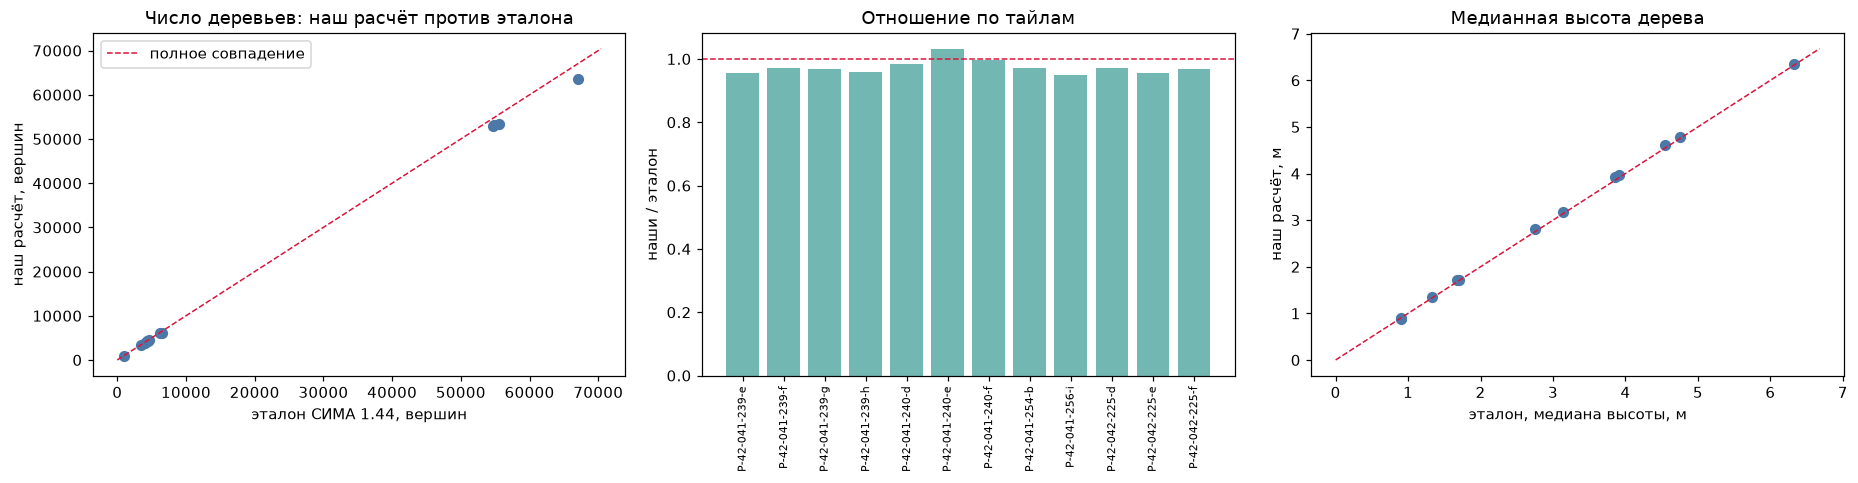

In [9]:
if len(base):
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

    axes[0].scatter(base['эталон'], base['наши'], s=40, color='#4C78A8')
    lim = [0, max(base['эталон'].max(), base['наши'].max()) * 1.05]
    axes[0].plot(lim, lim, ls='--', color='crimson', lw=1, label='полное совпадение')
    axes[0].set_xlabel('эталон СИМА 1.44, вершин'); axes[0].set_ylabel('наш расчёт, вершин')
    axes[0].set_title('Число деревьев: наш расчёт против эталона'); axes[0].legend()

    axes[1].bar(range(len(base)), base['отношение'], color='#72B7B2')
    axes[1].axhline(1.0, color='crimson', ls='--', lw=1)
    axes[1].set_xticks(range(len(base)))
    axes[1].set_xticklabels(base['tile'], rotation=90, fontsize=7)
    axes[1].set_ylabel('наши / эталон'); axes[1].set_title('Отношение по тайлам')

    axes[2].scatter(base['H эталон'], base['H медиана'], s=40, color='#4C78A8')
    lim = [0, max(base['H эталон'].max(), base['H медиана'].max()) * 1.05]
    axes[2].plot(lim, lim, ls='--', color='crimson', lw=1)
    axes[2].set_xlabel('эталон, медиана высоты, м'); axes[2].set_ylabel('наш расчёт, м')
    axes[2].set_title('Медианная высота дерева')

    plt.tight_layout(); plt.show()

## 9. Влияние разрешения

Окно поиска задаётся в метрах, но переводится в целое число пикселей, поэтому его
фактический поперечник зависит от сетки: `2 · radius_px · res + res`. При окне 1 м
это 2.5 м на сетке 0.5 м и 3.0 м на сетке 1.0 м — то есть переход на метровую сетку
сам по себе расширяет окно. Плюс на грубой сетке соседние кроны сливаются в один
максимум. Таблица ниже показывает суммарный эффект.

,вершин,"окно, м","радиус, px",от эталона
res_m,,,,
0.5,256804,2.5,2,0.969
1.0,164648,3.0,1,0.656


Переход с 0.5 м на 1.0 м теряет 35.9 % вершин (256,804 → 164,648)


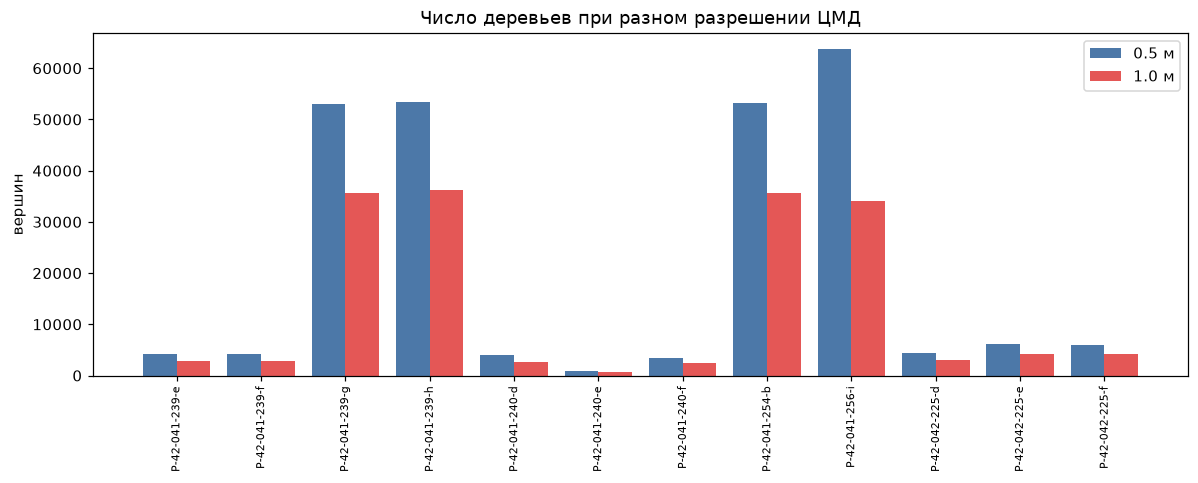

In [10]:
if len(df['res_m'].unique()) > 1:
    pivot = df.pivot_table(index='tile', columns='res_m',
                           values=['наши', 'window_m'], aggfunc='first')
    counts = pivot['наши']
    summary = pd.DataFrame({
        'вершин': counts.sum(),
        'окно, м': df.groupby('res_m')['window_m'].first(),
        'радиус, px': df.groupby('res_m')['window_px'].first(),
        'от эталона': df.groupby('res_m')['отношение'].median(),
    }).round(3)
    display(summary)

    fine, coarse = RESOLUTION, COMPARE_RESOLUTIONS[0]
    if fine in counts and coarse in counts:
        loss = 100 * (1 - counts[coarse].sum() / counts[fine].sum())
        print(f'Переход с {fine} м на {coarse} м теряет {loss:.1f} % вершин '
              f'({counts[fine].sum():,} → {counts[coarse].sum():,})')

    fig, ax = plt.subplots(figsize=(11, 4.5))
    x = np.arange(len(counts))
    ax.bar(x - 0.2, counts[fine], width=0.4, label=f'{fine} м', color='#4C78A8')
    ax.bar(x + 0.2, counts[coarse], width=0.4, label=f'{coarse} м', color='#E45756')
    ax.set_xticks(x); ax.set_xticklabels(counts.index, rotation=90, fontsize=7)
    ax.set_ylabel('вершин'); ax.set_title('Число деревьев при разном разрешении ЦМД')
    ax.legend(); plt.tight_layout(); plt.show()
else:
    print('Сравнение разрешений отключено (COMPARE_RESOLUTIONS пуст)')

## 10. ЦМД по ВЛС и по ВЛС + АФС

Расчёт ЦМД снимка не требует: всё выше посчитано по одному облаку. Снимок —
надстройка, которая делает с готовыми вершинами две вещи:

* **отсев** — вершина вне вегетационной маски не дерево (столб, техника, бровка
  отвала возвышаются над землёй и дают такой же локальный максимум высоты);
* **уточнение** — вершина сдвигается к центру связной области кроны на снимке,
  но не дальше `refine_radius_m`: дальний сдвиг означает слитный полог, и там
  положение по ЦМД надёжнее.

Канала ближнего ИК нет, поэтому NDVI неприменим и маска строится по RGB-индексу
ExG. Из этого следует ограничение: тень, вода и переувлажнённые участки уходят из
маски вместе с настоящими деревьями, поэтому отсев по RGB склонен убирать лишнее.
Ячейка ниже показывает, сколько именно.

In [11]:
def compare_afs(stem, resolution=None, window_m=None):
    # Один тайл в двух режимах: только ВЛС и ВЛС + АФС
    resolution = RESOLUTION if resolution is None else resolution
    window_m = WINDOW_M if window_m is None else window_m
    las_key, las_size = LAS_INDEX[stem]
    local = CACHE_DIR / PurePosixPath(las_key).name
    if not (local.exists() and local.stat().st_size == las_size):
        s3.download_file(BUCKET, las_key, str(local))
    tile_dir = WORK_ROOT / f'{stem}_afs'
    tile_dir.mkdir(parents=True, exist_ok=True)

    ref_n, _, ref_crs = load_reference(stem, tile_dir)
    built = CHMBuilder(output=str(tile_dir), crs=ref_crs,
                       config=CHMConfig(resolution=resolution)).build(
                           str(local), crs_wkt=ref_crs)
    chm, transform, res = read_chm(built.chm)

    t0 = time.perf_counter()
    tops = detect_tree_tops(chm, resolution_m=res, window_m=window_m,
                            min_height_m=MIN_HEIGHT_M, smooth_radius_px=MEDIAN_PX)
    t_vls = (time.perf_counter() - t0) * 1000

    with rasterio.open(built.chm) as src:
        bounds = src.bounds
    t0 = time.perf_counter()
    veg = build_afs_mask(stem, chm.shape, bounds)
    corr = (correct_tops(tops.rows, tops.cols, veg, resolution_m=res)
            if veg is not None else None)
    t_afs = (time.perf_counter() - t0) * 1000

    return {'stem': stem, 'chm': chm, 'transform': transform, 'res': res,
            'tops': tops, 'veg': veg, 'corr': corr, 'ref_n': ref_n,
            'ms_vls': t_vls, 'ms_afs': t_afs, 'tile_dir': str(tile_dir),
            'local_las': str(local)}


AFS_COMPARE_TILES = [n for n in SELECTED if n in AFS_INDEX][:3]
afs_runs = [compare_afs(n) for n in AFS_COMPARE_TILES]

rows = []
for r in afs_runs:
    c = r['corr']
    n_vls = len(r['tops'])
    n_afs = int(c.keep.sum()) if c is not None else n_vls
    shift = c.shift_px[c.shift_px > 0] * r['res'] if c is not None else np.empty(0)
    rows.append({
        'tile': r['stem'],
        'эталон': r['ref_n'],
        'только ВЛС': n_vls,
        'ВЛС + АФС': n_afs,
        'отсеяно': n_vls - n_afs,
        'отсеяно, %': 100 * (n_vls - n_afs) / n_vls if n_vls else 0,
        'сдвинуто': int(c.moved) if c is not None else 0,
        'сдвиг медиана, м': float(np.median(shift)) if shift.size else 0.0,
        'ВЛС / эталон': n_vls / r['ref_n'] if r['ref_n'] else None,
        'ВЛС+АФС / эталон': n_afs / r['ref_n'] if r['ref_n'] else None,
        'вегетация, %': 100 * float(r['veg'].mean()) if r['veg'] is not None else None,
        'мс: детекция': round(r['ms_vls'], 1),
        'мс: АФС': round(r['ms_afs'], 1),
    })
afs_df = pd.DataFrame(rows).round(3)
display(afs_df.set_index('tile'))

tot_vls, tot_afs = afs_df['только ВЛС'].sum(), afs_df['ВЛС + АФС'].sum()
print(f'Итого: только ВЛС {tot_vls:,} деревьев, с АФС {tot_afs:,} '
      f'({100 * (tot_vls - tot_afs) / tot_vls:.1f} % отсеяно)')
print(f'Эталон СИМА 1.44: {afs_df["эталон"].sum():,} — он посчитан без снимка, '
      f'поэтому ближе к режиму «только ВЛС»')
print(f'Цена АФС: +{afs_df["мс: АФС"].sum() / afs_df["мс: детекция"].sum():.0f}x '
      f'ко времени детекции (чтение снимка по сети и построение маски)')

,эталон,только ВЛС,ВЛС + АФС,отсеяно,"отсеяно, %",сдвинуто,"сдвиг медиана, м",ВЛС / эталон,ВЛС+АФС / эталон,"вегетация, %",мс: детекция,мс: АФС
tile,,,,,,,,,,,,
P-42-041-239-e,4471,4273,4083,190,4.447,2,0.785,0.956,0.913,80.506,13.0,2506.9
P-42-041-239-f,4358,4235,4055,180,4.250,1,0.829,0.972,0.930,81.423,13.1,1966.7
P-42-041-239-g,54728,52989,49144,3845,7.256,5,0.354,0.968,0.898,91.882,147.8,2840.0


Итого: только ВЛС 61,497 деревьев, с АФС 57,282 (6.9 % отсеяно)
Эталон СИМА 1.44: 63,557 — он посчитан без снимка, поэтому ближе к режиму «только ВЛС»
Цена АФС: +42x ко времени детекции (чтение снимка по сети и построение маски)


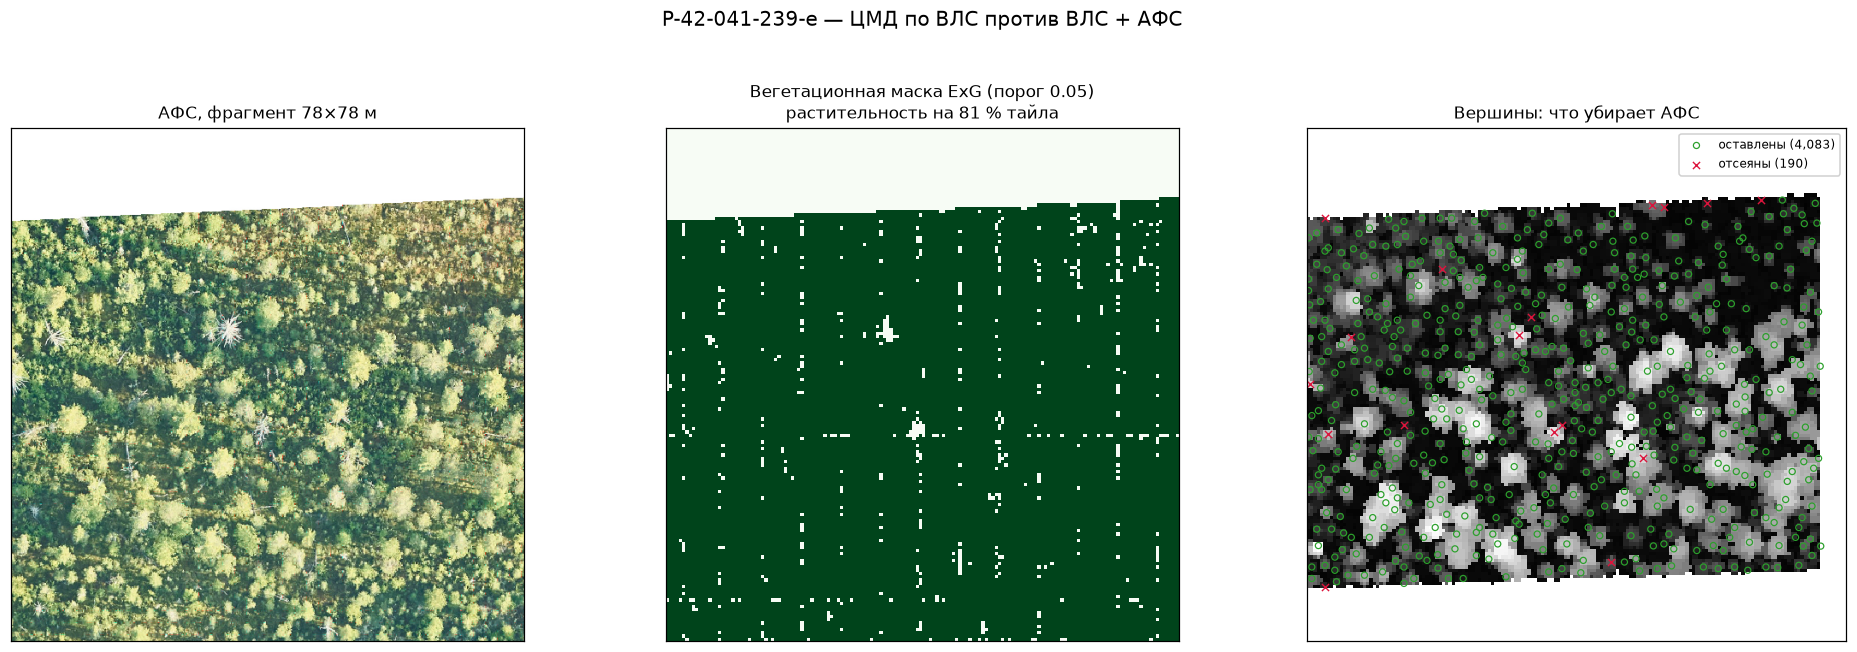

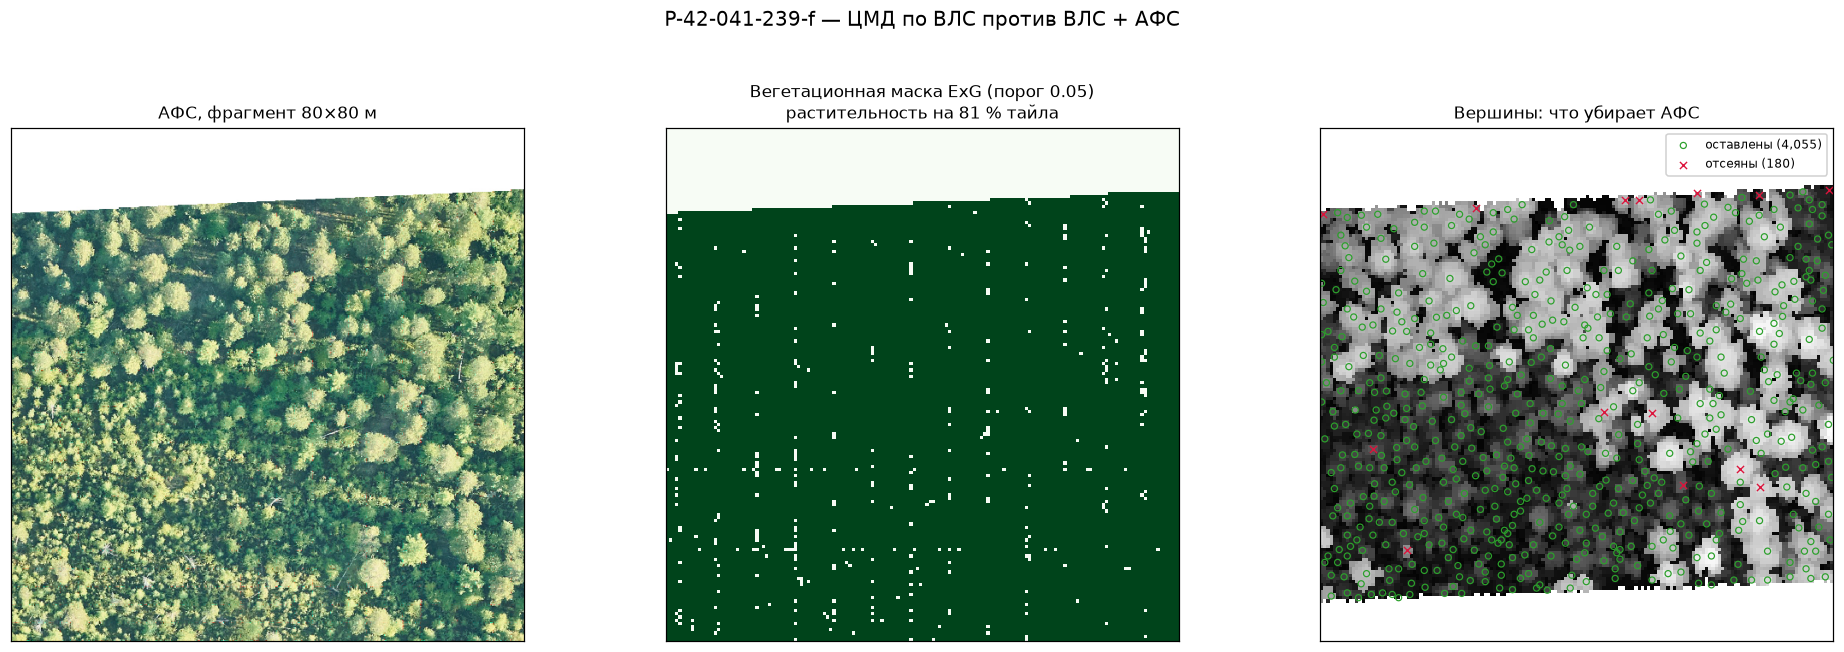

In [12]:
for r in afs_runs[:2]:
    if r['veg'] is None:
        continue
    chm, res, c = r['chm'], r['res'], r['corr']
    zoom = min(160, chm.shape[0], chm.shape[1])
    r0 = max(0, (chm.shape[0] - zoom) // 2)
    c0 = max(0, (chm.shape[1] - zoom) // 2)
    sl = (slice(r0, r0 + zoom), slice(c0, c0 + zoom))
    side = zoom * res

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    with rasterio.Env(GDAL_DISABLE_READDIR_ON_OPEN='NO'):
        with rasterio.open(vsis3(AFS_INDEX[r['stem']][0])) as src:
            b = rasterio.transform.array_bounds(zoom, zoom,
                                                r['transform'] * rasterio.Affine.translation(c0, r0))
            win = from_bounds(b[0], b[1], b[2], b[3],
                              transform=src.transform).round_offsets().round_lengths()
            rgb = np.transpose(src.read([1, 2, 3], window=win, boundless=True,
                                        fill_value=255, out_shape=(3, 600, 600)), (1, 2, 0))
    axes[0].imshow(rgb)
    axes[0].set_title(f'АФС, фрагмент {side:.0f}×{side:.0f} м', fontsize=11)

    axes[1].imshow(r['veg'][sl], cmap='Greens', interpolation='nearest')
    axes[1].set_title(f"Вегетационная маска ExG (порог {AFS_EXG_THRESHOLD})\n"
                      f"растительность на {100 * r['veg'].mean():.0f} % тайла", fontsize=11)

    axes[2].imshow(chm[sl], cmap='Greys_r')
    rr, cc = r['tops'].rows, r['tops'].cols
    inside = (rr >= r0) & (rr < r0 + zoom) & (cc >= c0) & (cc < c0 + zoom)
    kept = inside & c.keep
    dropped = inside & ~c.keep
    axes[2].scatter(cc[kept] - c0, rr[kept] - r0, s=16, facecolors='none',
                    edgecolors='#2ca02c', linewidths=0.8, label=f'оставлены ({int(c.keep.sum()):,})')
    axes[2].scatter(cc[dropped] - c0, rr[dropped] - r0, s=22, marker='x',
                    c='crimson', linewidths=0.9, label=f'отсеяны ({int((~c.keep).sum()):,})')
    axes[2].legend(loc='upper right', fontsize=8, framealpha=0.9)
    axes[2].set_title('Вершины: что убирает АФС', fontsize=11)

    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"{r['stem']} — ЦМД по ВЛС против ВЛС + АФС", fontsize=13)
    fig.tight_layout(rect=(0, 0, 1, 1 - 0.55 / fig.get_figheight()))
    fig.savefig(PREVIEW_DIR / f"{r['stem']}_afs_compare.png", dpi=110, bbox_inches='tight')
    plt.show()

for r in afs_runs:
    shutil.rmtree(r['tile_dir'], ignore_errors=True)
    if not CACHE_LAS:
        Path(r['local_las']).unlink(missing_ok=True)

## 11. Время по шагам

,"сумма, с","доля, %","медиана, мс","p95, мс"
reference,153.72,47.77,1714.50,11568.53
chm,80.23,24.93,852.40,12647.84
download,65.56,20.37,904.85,7794.25
write,14.79,4.60,157.35,2037.42
crowns,6.50,2.02,66.85,1029.42
treetops,1.01,0.31,15.00,161.88


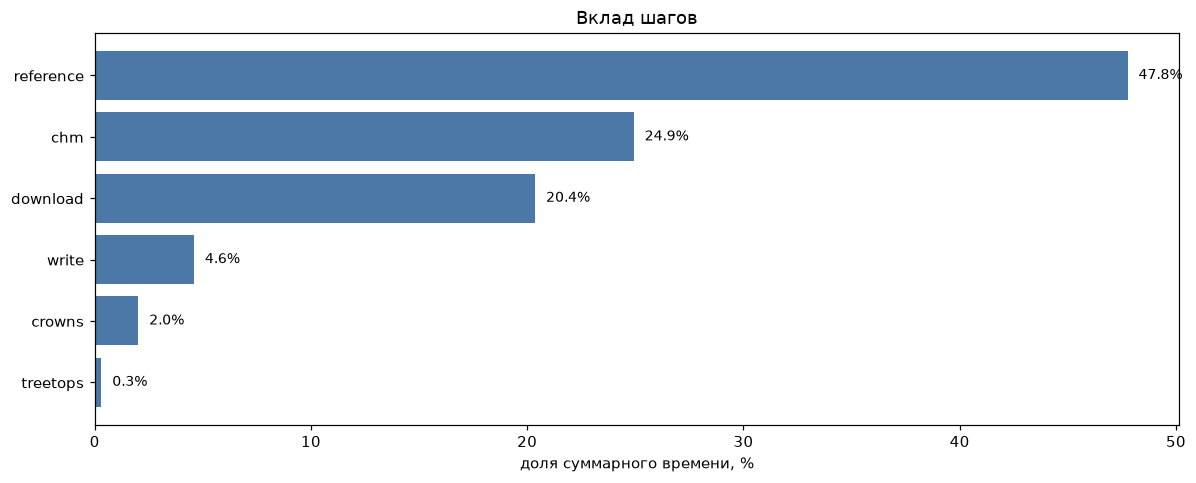

In [13]:
steps = pd.DataFrame([{**{'tile': r['name'], 'res_m': r['resolution']}, **r.get('steps', {})}
                      for r in ok]).fillna(0)
cols = [c for c in ('download', 'reference', 'chm', 'treetops', 'afs', 'crowns', 'write')
        if c in steps]
by_res = steps.groupby('res_m')[cols].sum() / 1000

display(pd.DataFrame({
    'сумма, с': steps[cols].sum() / 1000,
    'доля, %': 100 * steps[cols].sum() / steps[cols].sum().sum(),
    'медиана, мс': steps[cols].median(),
    'p95, мс': steps[cols].quantile(.95),
}).sort_values('доля, %', ascending=False).round(2))

fig, ax = plt.subplots(figsize=(11, 4.5))
share = (steps[cols].sum() / steps[cols].sum().sum() * 100).sort_values()
ax.barh(share.index, share.values, color='#4C78A8')
for i, v in enumerate(share.values):
    ax.text(v + .5, i, f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlabel('доля суммарного времени, %'); ax.set_title('Вклад шагов')
plt.tight_layout(); plt.show()

## 12. Итог

In [14]:
print(f'Датасет:           Юильский, {len(TILES)} тайлов со сверяемым эталоном')
print(f'Обработано:        {len(base)} тайлов на {RESOLUTION} м (ошибок {len(bad)})')
print(f'Параметры:         ЦМД {RESOLUTION} м, окно {WINDOW_M} м '
      f'({base["window_px"].iloc[0] if len(base) else "?"} px), медиана {MEDIAN_PX} px')
if len(base):
    ratio = base['отношение'].dropna()
    print(f'Сходимость:        {ratio.median():.3f}× от эталона СИМА 1.44 '
          f'(диапазон {ratio.min():.3f}…{ratio.max():.3f})')
    print(f'Высота:            расхождение медиан '
          f"{(base['H медиана'] - base['H эталон']).abs().median():.2f} м")
    print(f'Найдено деревьев:  {int(base["наши"].sum()):,} против {int(base["эталон"].sum()):,} '
          f'в эталоне')
print(f'Время:             медиана {base["время, с"].median():.1f} с на тайл'
      if len(base) else '')
print(f'Картинок:          {len(list(PREVIEW_DIR.glob("*.png")))} → {PREVIEW_DIR}')
print(f'JSONL:             {RESULTS_PATH}')

Датасет:           Юильский, 598 тайлов со сверяемым эталоном
Обработано:        12 тайлов на 0.5 м (ошибок 0)
Параметры:         ЦМД 0.5 м, окно 1.0 м (2 px), медиана 1 px
Сходимость:        0.969× от эталона СИМА 1.44 (диапазон 0.950…1.030)
Высота:            расхождение медиан 0.04 м
Найдено деревьев:  256,804 против 266,753 в эталоне
Время:             медиана 3.8 с на тайл
Картинок:          5 → /Users/sergeyzay/Documents/НЕДРА/СИМА/sima-web/backend/benchmarks/results_s3_forest_yuilskiy/previews
JSONL:             /Users/sergeyzay/Documents/НЕДРА/СИМА/sima-web/backend/benchmarks/results_s3_forest_yuilskiy/results.jsonl
